In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 습관처럼 무조건
print(device)

print(torch.__version__)

cuda
2.11.0+cu128


In [3]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
def perceptron_and(x1, x2):
    w = torch.tensor([0.5, 0.5])
    b = torch.tensor(-0.7)
    x = torch.tensor([x1, x2], dtype = torch.float32)
    output = torch.dot(w, x) + b
    return 1 if output >= 0 else 0

print(perceptron_and(0, 0))
print(perceptron_and(0, 1))
print(perceptron_and(1, 0))
print(perceptron_and(1, 1))

0
0
0
1


In [5]:
class SimpleNN(nn.Module):
    def __init__(self): # 클래스 생성시 무조건 있어야함 init
        super(SimpleNN, self).__init__()
        # nn.Linear (들어오는 개수, 나가는 개수)
        self.fc1 = nn.Linear(2, 3)
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = SimpleNN()
sample_input = torch.tensor([1.0, 2.0])
output = model(sample_input)
print(output)

tensor([0.6693], grad_fn=<SigmoidBackward0>)


In [6]:
# 기본 신경망 구조
class SimpleNN_Full(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN_Full, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN_Full(input_size=10, hidden_size=20, output_size=1)
print(model)

for param in model.parameters():
    print(param.shape)

SimpleNN_Full(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)
torch.Size([20, 10])
torch.Size([20])
torch.Size([1, 20])
torch.Size([1])


In [7]:
# 데이터셋 사용법
X_train = torch.randn(100, 10)
y_train = torch.randn(100, 1)
dataset = TensorDataset(X_train, y_train)

dataloader = DataLoader(dataset, batch_size = 32, shuffle = True) # shuffle = True는 반드시 기억

In [8]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    for batch in dataloader:
        inputs, targets = batch
        optimizer.zero_grad() # 이전에 학습된것에 대해(두번째부터) 잊으라는 / 기울기를 이전 기울기는 초기화 시키는 개념
        outputs = model(inputs) # 순전파
        loss = criterion(outputs, targets) # ()안에 순서를 기억할것 / (예측값, 정답) 으로 loss계산
        loss.backward() # 로스만큼 검산하면서 확인하면서 계산하면서 나가보자
        optimizer.step() # 파라메타를 다음스탭으로 즉, 파라메타를 바꿔서 사용해보자
    print(epoch + 1, loss.item())

1 0.9306035041809082
2 1.979332447052002
3 0.524667501449585
4 0.9314338564872742
5 2.472566843032837
6 1.977538824081421
7 2.6563892364501953
8 1.100563645362854
9 1.5428667068481445
10 0.08924788981676102


In [9]:
torch.save(model.state_dict(), "model.pth")
model = SimpleNN_Full(input_size = 10, hidden_size = 20, output_size = 1)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [10]:
# 손실이 NaN이 되었을때

def check_nan_loss(loss, optimizer):
    if torch.isnan(loss).any():
        print("Loss에 NaN이 포함되어 있음")

        for param_group in optimizer.param_groups:
            param_group["lr"] *= 0.1 # NaN이 포함되어있으면 학습능률을 10%로 낮출것
        return True
    return False

sample_loss = torch.tensor(float("nan"))
nan_detected = check_nan_loss(sample_loss, optimizer)
print(nan_detected)

Loss에 NaN이 포함되어 있음
True


In [11]:
# 데이터 증강
transform = transforms.Compose([transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(10),
                                transforms.ToTensor()])

In [12]:
# MNIST
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = torchvision.datasets.MNIST(root = "./data",
                                           train = True,
                                           transform = transform,
                                           download = True)

test_dataset = torchvision.datasets.MNIST(root = "./data",
                                           train = False,
                                           transform = transform,
                                           download = True)

In [13]:
train_loader = DataLoader(dataset = train_dataset,
                          batch_size = 64,
                          shuffle = True)

test_loader = DataLoader(dataset = test_dataset,
                         batch_size = 1000,
                         shuffle = False)

print(len(train_loader))
print(len(test_loader))

938
10


In [14]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [15]:
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [16]:
for epoch in range(10):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(epoch + 1, loss.item())

1 0.25291579961776733
2 0.2146015167236328
3 0.0859103798866272
4 0.020982526242733
5 0.02018461748957634
6 0.0019541585352271795
7 0.00017118958930950612
8 0.008578936569392681


KeyboardInterrupt: 

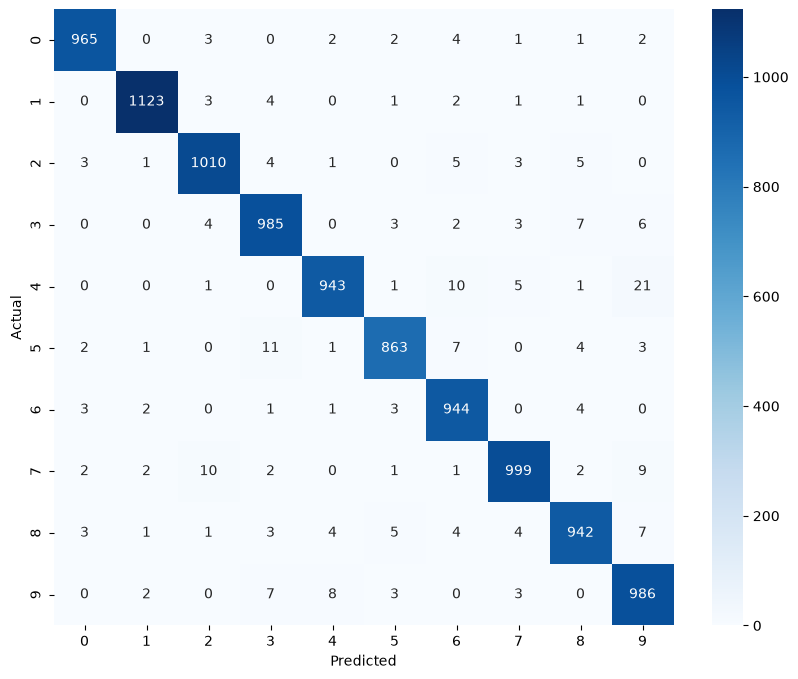

In [ ]:
# 혼동행렬
model.eval()
all_targets = []
all_preds = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        all_targets.extend(target.cpu().numpy()) # 혼동행렬을 구할때 sklearn은 gpu를 모르기때문에 cpu로 보내줌 > numpy로 변경
        all_preds.extend(predicted.cpu().numpy())

targets = np.array(all_targets)
preds = np.array(all_preds)

cm_mnist = confusion_matrix(targets, preds) # 혼동행렬을 구할때는 정답을 먼저주고 예측치를 줌
plt.figure(figsize = (10, 8))
sns.heatmap(cm_mnist,
            annot = True,
            fmt = "d",
            cmap = "Blues",
            xticklabels = range(10),
            yticklabels = range(10))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

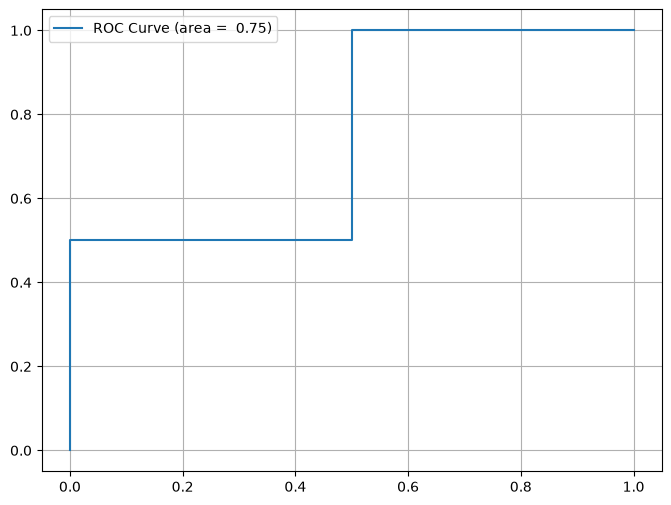

In [ ]:
y_scores = np.array([0.1, 0.4, 0.35, 0.8])
y_test = np.array([0, 0, 1, 1])

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, label = f"ROC Curve (area = {roc_auc : .2f})")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer,
                              mode = "min",
                              patience = 3,
                              factor = 0.1)
for epoch in range(50):
    # train_one_epoch(model, train_loader.......)
    # val_loss = evaluate(model, val_loader)
    # scheduler.step(val_loss)
    train_loss = 0.2 * (50 - epoch)
    scheduler.step(train_loss)

In [ ]:
# 배치 정규화 모델 / 리니어 사이사이 BatchNorm1d이 들어감
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn1(self.fc2(x)))
        x = self.fc3(x)
        return x

In [ ]:
# 드랍아웃 추가
class MLP_BN_Dropout(nn.Module):
    def __init__(self, p=0.5):
        super(MLP_BN_Dropout, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(p)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(p)

        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.dropout1(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x